In [1]:
import os
import math
import requests
from dotenv import load_dotenv


# ==================================================
# 1. CONFIGURAÇÃO
# ==================================================

load_dotenv()

API_KEY = os.getenv("OPENROUTER_API_KEY")

URL = "https://openrouter.ai/api/v1/embeddings"
MODELO = "openai/text-embedding-3-small"


if not API_KEY:
    raise ValueError("Chave OPENROUTER_API_KEY não encontrada no arquivo .env")


# ==================================================
# 2. GERAR EMBEDDING
# ==================================================

def gerar_embedding(texto):

    response = requests.post(
        URL,
        headers={
            "Authorization": f"Bearer {API_KEY}",
            "Content-Type": "application/json"
        },
        json={
            "model": MODELO,
            "input": texto
        }
    )

    response.raise_for_status()

    dados = response.json()

    embedding = dados["data"][0]["embedding"]

    # tenta pegar o consumo de tokens retornado pela API
    usage = dados.get("usage", {})

    tokens = usage.get(
        "prompt_tokens",
        usage.get("total_tokens", 0)
    )

    return embedding, tokens


# ==================================================
# 3. SIMILARIDADE DE COSSENO
#
# Quanto MAIOR o valor, mais semelhantes.
# ==================================================

def similaridade_cosseno(vetor1, vetor2):

    produto_escalar = sum(
        a * b
        for a, b in zip(vetor1, vetor2)
    )

    norma1 = math.sqrt(
        sum(a * a for a in vetor1)
    )

    norma2 = math.sqrt(
        sum(b * b for b in vetor2)
    )

    return produto_escalar / (norma1 * norma2)


# ==================================================
# 4. DISTÂNCIA EUCLIDIANA
#
# Quanto MENOR o valor, mais próximos.
# ==================================================

def distancia_euclidiana(vetor1, vetor2):

    return math.sqrt(
        sum(
            (a - b) ** 2
            for a, b in zip(vetor1, vetor2)
        )
    )


# ==================================================
# 5. PALAVRAS
# ==================================================

palavras = [
    "gato",
    "felino",
    "cachorro",
    "carro",
    "caminhão",
    "moto",
    "banana",
    "maçã",
    "goiaba"
]


# ==================================================
# 6. GERAR EMBEDDINGS
# ==================================================

embeddings = {}
tokens_por_palavra = {}

total_tokens = 0


print("=" * 70)
print("GERANDO EMBEDDINGS")
print("=" * 70)


for palavra in palavras:

    embedding, tokens = gerar_embedding(palavra)

    embeddings[palavra] = embedding
    tokens_por_palavra[palavra] = tokens

    total_tokens += tokens

    print(
        f"{palavra:10} | "
        f"Dimensão: {len(embedding):4} | "
        f"Tokens: {tokens}"
    )


# ==================================================
# 7. TOTAL DE TOKENS
# ==================================================

print("\n" + "=" * 70)
print("CONSUMO DE TOKENS")
print("=" * 70)

for palavra in palavras:

    print(
        f"{palavra:10} -> "
        f"{tokens_por_palavra[palavra]} token(s)"
    )

print("-" * 70)

print("Total de tokens:", total_tokens)


# ==================================================
# 8. MOSTRAR OS PRIMEIROS 5 VALORES
# ==================================================

print("\n" + "=" * 70)
print("PRIMEIROS 5 VALORES DOS EMBEDDINGS")
print("=" * 70)

for palavra in palavras:

    print(
        f"{palavra:10} -> "
        f"{embeddings[palavra][:5]}"
    )


# ==================================================
# 9. COMPARAR TODAS AS PALAVRAS
# ==================================================

resultados = []


for i in range(len(palavras)):

    for j in range(i + 1, len(palavras)):

        palavra1 = palavras[i]
        palavra2 = palavras[j]

        vetor1 = embeddings[palavra1]
        vetor2 = embeddings[palavra2]

        similaridade = similaridade_cosseno(
            vetor1,
            vetor2
        )

        distancia = distancia_euclidiana(
            vetor1,
            vetor2
        )

        resultados.append({
            "palavra1": palavra1,
            "palavra2": palavra2,
            "similaridade": similaridade,
            "distancia": distancia
        })


# ==================================================
# 10. ORDENAR PELA MAIOR SIMILARIDADE
# ==================================================

resultados.sort(
    key=lambda x: x["similaridade"],
    reverse=True
)


# ==================================================
# 11. MOSTRAR TODAS AS COMPARAÇÕES
# ==================================================

print("\n" + "=" * 80)
print("COMPARAÇÃO ENTRE AS PALAVRAS")
print("=" * 80)

print(
    f"{'PALAVRA 1':12}"
    f"{'PALAVRA 2':12}"
    f"{'SIMILARIDADE':16}"
    f"{'DISTÂNCIA':12}"
)

print("-" * 55)


for resultado in resultados:

    print(
        f"{resultado['palavra1']:12}"
        f"{resultado['palavra2']:12}"
        f"{resultado['similaridade']:<16.4f}"
        f"{resultado['distancia']:.4f}"
    )


# ==================================================
# 12. TOP 5 MAIS PARECIDAS
# ==================================================

print("\n" + "=" * 70)
print("TOP 5 PALAVRAS MAIS PARECIDAS")
print("=" * 70)

for resultado in resultados[:5]:

    print(
        f"{resultado['palavra1']} <-> "
        f"{resultado['palavra2']} | "
        f"Similaridade: {resultado['similaridade']:.4f} | "
        f"Distância: {resultado['distancia']:.4f}"
    )


# ==================================================
# 13. TOP 5 MENOS PARECIDAS
# ==================================================

print("\n" + "=" * 70)
print("TOP 5 PALAVRAS MENOS PARECIDAS")
print("=" * 70)

for resultado in resultados[-5:]:

    print(
        f"{resultado['palavra1']} <-> "
        f"{resultado['palavra2']} | "
        f"Similaridade: {resultado['similaridade']:.4f} | "
        f"Distância: {resultado['distancia']:.4f}"
    )

GERANDO EMBEDDINGS
gato       | Dimensão: 1536 | Tokens: 2
felino     | Dimensão: 1536 | Tokens: 2
cachorro   | Dimensão: 1536 | Tokens: 3
carro      | Dimensão: 1536 | Tokens: 2
caminhão   | Dimensão: 1536 | Tokens: 4
moto       | Dimensão: 1536 | Tokens: 2
banana     | Dimensão: 1536 | Tokens: 1
maçã       | Dimensão: 1536 | Tokens: 3
goiaba     | Dimensão: 1536 | Tokens: 3

CONSUMO DE TOKENS
gato       -> 2 token(s)
felino     -> 2 token(s)
cachorro   -> 3 token(s)
carro      -> 2 token(s)
caminhão   -> 4 token(s)
moto       -> 2 token(s)
banana     -> 1 token(s)
maçã       -> 3 token(s)
goiaba     -> 3 token(s)
----------------------------------------------------------------------
Total de tokens: 22

PRIMEIROS 5 VALORES DOS EMBEDDINGS
gato       -> [-0.0016355514526367188, -0.03515625, -0.01751708984375, 0.034271240234375, -0.00732421875]
felino     -> [-0.00797271728515625, -0.0469970703125, -0.0088348388671875, 0.0244140625, 0.0068817138671875]
cachorro   -> [0.031707763671875, 

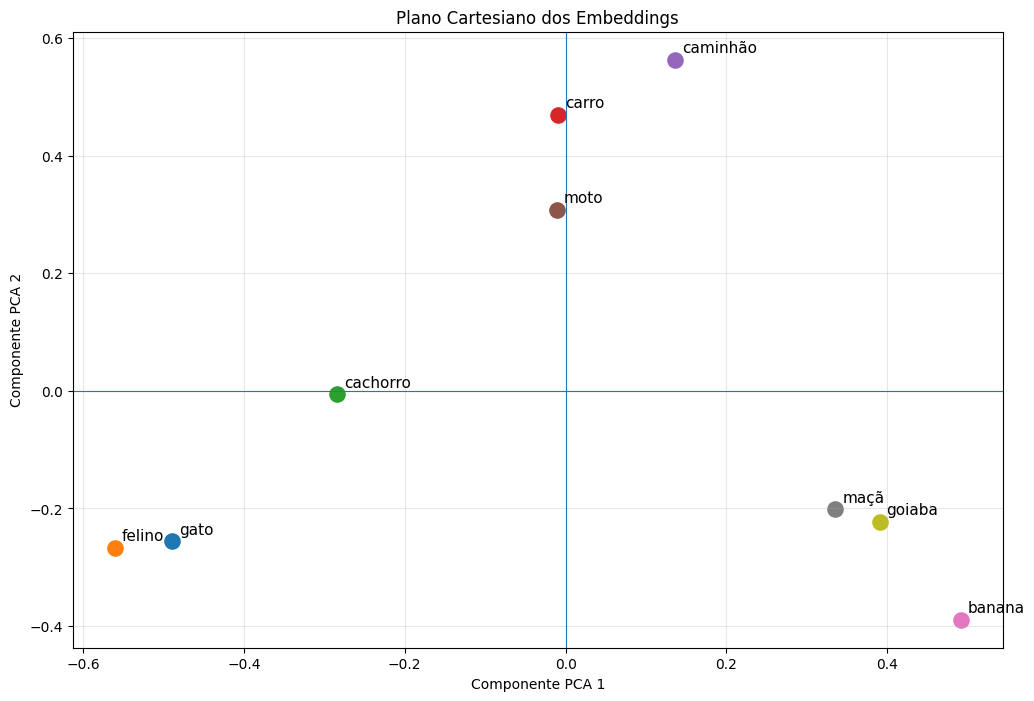

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Palavras
palavras = [
    "gato",
    "felino",
    "cachorro",
    "carro",
    "caminhão",
    "moto",
    "banana",
    "maçã",
    "goiaba"
]


# Transformar embeddings em matriz
matriz_embeddings = np.array([
    embeddings[palavra]
    for palavra in palavras
])


# Reduzir de 1536 dimensões para 2 dimensões
pca = PCA(n_components=2)

pontos_2d = pca.fit_transform(matriz_embeddings)


# Criar gráfico
plt.figure(figsize=(12, 8))


# Criar os pontos
for i, palavra in enumerate(palavras):

    x = pontos_2d[i, 0]
    y = pontos_2d[i, 1]

    # ponto
    plt.scatter(x, y, s=120)

    # nome da palavra
    plt.annotate(
        palavra,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11
    )


# Linha horizontal passando pelo zero
plt.axhline(0, linewidth=0.8)

# Linha vertical passando pelo zero
plt.axvline(0, linewidth=0.8)

# Grade do plano
plt.grid(True, alpha=0.3)


# Nomes dos eixos
plt.xlabel("Componente PCA 1")
plt.ylabel("Componente PCA 2")

plt.title(
    "Plano Cartesiano dos Embeddings"
)

plt.show()